In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Исходные точки
train_X = np.array([[0,2], [2,3], [2,0], [1,7], [3,4], [7,6]])
train_y = np.array([0, 0, 0, 1, 1, 1])
#Тестовые точки
X = np.array([[3,2], [6,0], [4,4]])

Матрица смежности: [0 0 1]


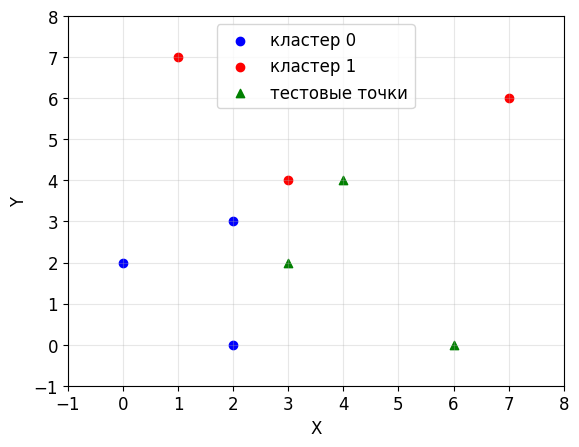

In [ ]:
#Вычисление матрицы расстояний
def compute_distances_no_loops(train_X, X):
  matrix = np.abs(train_X[:, np.newaxis, :] - X[np.newaxis, :, :])
  dists = np.sum(matrix, axis = 2)
  return dists
compute_distances_no_loops(train_X, X)

dists = compute_distances_no_loops(train_X, X)

#Определение к какому множеству какая точка относится
def predict_labels_binary(dists, train_y, k):
  num_test = dists.shape[1]
  pred = np.zeros(num_test, dtype = int)
  for i in range(num_test):
    nearest_indices = np.argsort(dists[:, i])[:k]
    neighbor_labels = train_y[nearest_indices]
    true_count = np.sum(neighbor_labels)
    false_count = k - true_count
    pred[i] = true_count > false_count
  return pred

predict = predict_labels_binary(dists, train_y, 1)
print(f'Матрица смежности: {predict}')

#Выводим на экран для наглядности
plt.scatter(train_X[train_y == 0, 0], train_X[train_y == 0, 1], color = 'blue', label = 'кластер 0')
plt.scatter(train_X[train_y == 1, 0], train_X[train_y == 1, 1], color = 'red', label = 'кластер 1')
pred = np.array(predict)
plt.rcParams['font.size'] = 12
plt.scatter(X[:,0], X[:,1], marker='^', color = 'green', label = 'тестовые точки')
plt.grid()
plt.xlim(-1, 8)
plt.ylim(-1, 8)
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha = 0.3)
plt.legend(loc = 'upper center', fontsize = 12)
plt.savefig('k-NN123.pdf')